Test - update notebook - Jovana

Test - update notebook - Sonja

# PRML - Course Project
## Comparative Study of Classical Methods on the Diamonds Dataset

In this project we perform two supervised-learning tasks on the same dataset:

1. **Classification** - predict whether a diamond has a premium cut
   (`Premium` = {Premium, Ideal}) or not (`Non-Premium` = {Fair, Good, Very Good}).
2. **Regression** - predict a diamond's price.

Baseline methods:
* Classification: Gaussian Naive Bayes and k-NN classification.
* Regression: Linear Regressionand k-NN regression.

Extension: Random Forest for both tasks.

All the models are implemented from scratch, and the external libraries (`scikit-learn`) are used only for validation/comparison.

### Dataset

The **Diamonds** dataset contains 53,940 round-cut diamonds with 10 attributes:

- `carat` (weight)
- `cut` (quality, 5 grades),
- `color` (D best, J worst),
- `clarity` (IF best, I1 worst)
- `depth` (total depth percentage)
- `table` (table width percentage)
- physical dimensions `x, y, z` (mm)
- `price` (USD)

# Data loading

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(0)

In [ ]:
df = pd.read_csv('/content/diamonds.csv')

print('dataset shape:', df.shape)
print(df.head())
print("\n")
print(df.info())

dataset shape: (53940, 11)
   Unnamed: 0  carat      cut color clarity  depth  table  price     x     y  \
0           1   0.23    Ideal     E     SI2   61.5   55.0    326  3.95  3.98   
1           2   0.21  Premium     E     SI1   59.8   61.0    326  3.89  3.84   
2           3   0.23     Good     E     VS1   56.9   65.0    327  4.05  4.07   
3           4   0.29  Premium     I     VS2   62.4   58.0    334  4.20  4.23   
4           5   0.31     Good     J     SI2   63.3   58.0    335  4.34  4.35   

      z  
0  2.43  
1  2.31  
2  2.31  
3  2.63  
4  2.75  


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  53940 non-null  int64  
 1   carat       53940 non-null  float64
 2   cut         53940 non-null  object 
 3   color       53940 non-null  object 
 4   clarity     53940 non-null  object 
 5   depth       53940 non-null  f

In [ ]:
df = df.drop(columns=['Unnamed: 0'])
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


## Data cleaning

In [ ]:
# Check if any numerical column has 0 values
numeric_cols = ['carat','depth','table','price','x','y','z']
zeros = (df[numeric_cols] == 0).sum()
print("Zero counts per numerical column:")
print(zeros[zeros > 0])

Zero counts per numerical column:
x     8
y     7
z    20
dtype: int64


In [ ]:
# It is impossible for a diamond do have 0 for a physical dimension, so we remove those rows from the dataset
bad = (df['x'] == 0) | (df['y'] == 0) | (df['z'] == 0)
df = df[~bad].reset_index(drop=True)
print(bad.sum(), 'dropped')

20 dropped


## EDA


Numerical summary:


,carat,depth,table,price,x,y,z
count,53920.000000,53920.000000,53920.000000,53920.000000,53920.000000,53920.000000,53920.000000
mean,0.797698,61.749514,57.456834,3930.993231,5.731627,5.734887,3.540046
std,0.473795,1.432331,2.234064,3987.280446,1.119423,1.140126,0.702530
min,0.200000,43.000000,43.000000,326.000000,3.730000,3.680000,1.070000
25%,0.400000,61.000000,56.000000,949.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5323.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


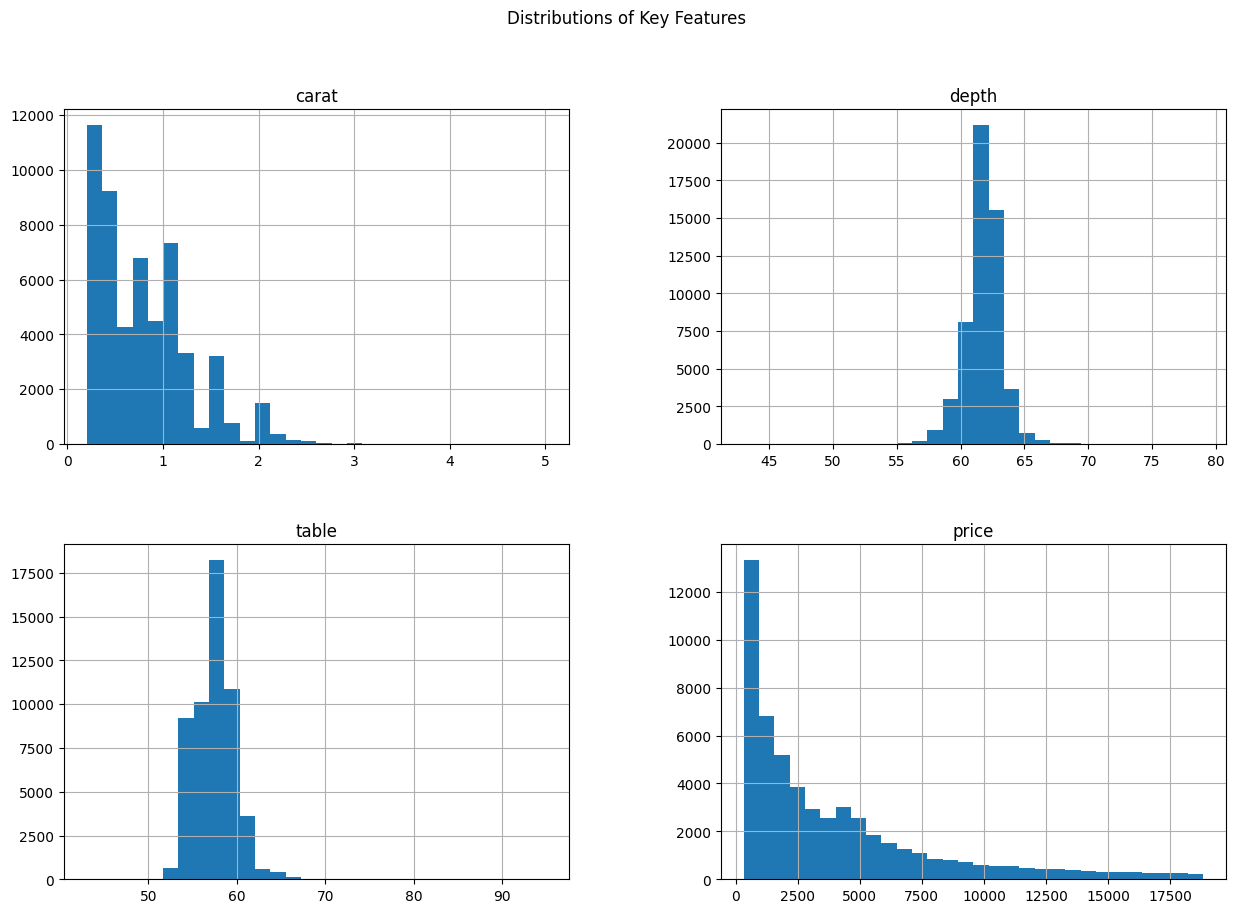

In [ ]:
# Summary statistics
print("\nNumerical summary:")
display(df.describe())

print("\n")

# Visualize distributions of main numerical features
df[['carat', 'depth', 'table', 'price']].hist(bins=30, figsize=(15, 10))
plt.suptitle("Distributions of Key Features")
plt.show()

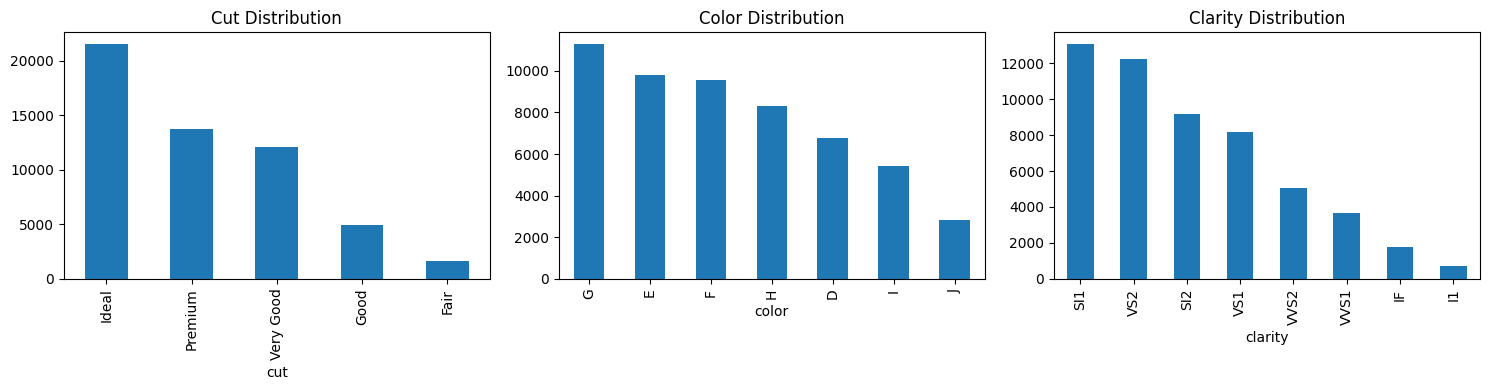

In [ ]:
# Categorical distributions
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

df['cut'].value_counts().plot(kind='bar', ax=ax[0], title='Cut Distribution')
df['color'].value_counts().plot(kind='bar', ax=ax[1], title='Color Distribution')
df['clarity'].value_counts().plot(kind='bar', ax=ax[2], title='Clarity Distribution')

plt.tight_layout()
plt.show()

## Data preparation

### Feature engineering

New features:

- `color_ord`, `clarity_ord`, `cut_ord` - from categorical to ordinal. `cut_ord` is used only in regression (cut builds the premium target).
- `volume` - x*y*z, size.
- `log_carat`
- `log_price`
- `price_per_carat` - price/carat

In [ ]:
COLOR_ORD   = {'J': 1, 'I': 2, 'H': 3, 'G': 4, 'F': 5, 'E': 6, 'D': 7}
# J = worst, D = best (GIA scale, not alphabetical order)
CLARITY_ORD = {'I1': 1, 'SI2': 2, 'SI1': 3, 'VS2': 4, 'VS1': 5, 'VVS2': 6, 'VVS1': 7, 'IF': 8}
# I1 = worst, IF = best
CUT_ORD     = {'Fair': 1, 'Good': 2, 'Very Good': 3, 'Premium': 4, 'Ideal': 5}

def add_features(d):
    d = d.copy()
    d['color_ord']   = d['color'].map(COLOR_ORD)
    d['clarity_ord'] = d['clarity'].map(CLARITY_ORD)
    d['cut_ord']     = d['cut'].map(CUT_ORD)
    d['volume']      = d['x'] * d['y'] * d['z']
    d['log_carat']   = np.log(d['carat'])
    d['log_price']   = np.log(d['price'])
    d['price_per_carat'] = d['price'] / d['carat']
    return d

data = add_features(df)
print('features added:', [c for c in data.columns if c not in df.columns])

features added: ['color_ord', 'clarity_ord', 'cut_ord', 'volume', 'log_carat', 'log_price', 'price_per_carat']


In [ ]:
# Stratified 6,000-row subsample (stratified on target to preserve class proportions)
def stratified_sample(d, col, n, seed=0):
    frac = n / len(d)
    parts = [g.sample(frac=frac, random_state=seed) for _, g in d.groupby(col)]
    return pd.concat(parts).sample(frac=1, random_state=seed).reset_index(drop=True)

sample = stratified_sample(data, 'cut', 6000, seed=0)
print('subsample shape:', sample.shape)

subsample shape: (5999, 17)



# Part A - Classification (premium vs non-premium cut)

### Research questions:
**RQ1** - Can the premium/non-premium cut be recovered from a diamond's attributes?

**RQ2** - What are the strongest discriminators?

**RQ3** - Which model separates the classes
best, and how do their hyperparameters matter?

In [ ]:
CLASS_NAMES = ['Non-Premium', 'Premium']
sample['premium'] = sample['cut'].isin(['Premium', 'Ideal']).astype(int)

print("Original cut distribution:")
print(sample['cut'].value_counts())

counts = sample['premium'].value_counts().sort_index()
print('\nBinary target (premium):')
print(counts.rename(index=dict(enumerate(CLASS_NAMES))))
print('proportions:', (counts / counts.sum()).round(3).to_dict())

plt.figure()
plt.bar(CLASS_NAMES, counts.values)
plt.title('Premium vs Non-Premium balance')
plt.ylabel('number of diamonds')
plt.show()

**Note**:
- split is 65/35 (Premium vs Non-Premium)  
- moderately imbalanced, not extreme.
- We use macro-F1 alongside accuracy instead of resampling.

### Feature Correlations

In [ ]:
CLF_FEATURES = ['carat', 'depth', 'table', 'color_ord', 'clarity_ord', 'volume',
                'log_price', 'price_per_carat', 'x', 'y', 'z']

corr = pd.Series({f: np.corrcoef(sample[f], sample['premium'])[0, 1] for f in CLF_FEATURES}).sort_values()
plt.figure(figsize=(7, 5))
plt.barh(corr.index, corr.values)
plt.axvline(0, color='k', lw=0.8)
plt.title('Correlation of each feature with the premium label')
plt.tight_layout()
plt.show()
print(corr.round(3))

In [ ]:
def plot_stratified_dist(df, feature, title_suffix, x_label, x_lim=None):
    fig, ax = plt.subplots(1, 2, figsize=(15, 5))
    for cls in [0, 1]:
        ax[cls].hist(df.loc[df['premium'] == cls, feature], bins=60, color='C'+str(cls+4), alpha=0.7)
        ax[cls].set_title(f'{title_suffix}: {CLASS_NAMES[cls]}')
        ax[cls].set_xlabel(x_label)
        if x_lim: ax[cls].set_xlim(x_lim)
    plt.tight_layout()
    plt.show()

plot_stratified_dist(sample, 'volume', 'Volume Distribution', 'Volume (mm^3)', (0, 600))